# Group Work Project 2: Regime-Based Asset Allocation Strategy

## Overview

This notebook presents a complete regime-based asset allocation framework using TLT, GLD, SPY, and the VIX. We organize the analysis into five steps: data preparation, regime estimation, state selection and interpretation, strategy construction, and backtesting.

## Package Installation and Imports

In [1]:
!pip install --upgrade yfinance hmmlearn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
import seaborn as sns
from scipy import stats
import yfinance as yf
import warnings
from IPython.display import Javascript, display
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
np.set_printoptions(precision=6, suppress=True)

## Step 1: Data Preparation and Exploration

### Purpose

We initiate our analysis by constructing a robust empirical dataset. We aggregate daily adjusted close prices for TLT, GLD, SPY, and the VIX, aligning them to a common historical sample. Our primary objective is to derive ETF log-returns and identify a suitable volatility proxy. We specifically focus on daily VIX changes to capture the shifting sentiment and fear levels that drive market regimes.

STEP 1: DATA PREPARATION AND EXPLORATION


Download complete
First date in common sample: 2004-11-18
Last date in common sample: 2026-05-19
Number of observations: 5408

Raw aligned price data (first 5 rows):


Ticker,TLT,GLD,SPY,VIX
Date,,,,
2004-11-18,44.161678,44.380001,79.950706,12.980000
2004-11-19,43.809280,44.779999,79.061905,13.500000
2004-11-22,44.037617,44.950001,79.438988,12.970000
2004-11-23,44.092205,44.750000,79.560173,12.670000
2004-11-24,44.092205,45.049999,79.748734,12.720000



Raw aligned price data (last 5 rows):


Ticker,TLT,GLD,SPY,VIX
Date,,,,
2026-05-13,84.800003,430.500000,742.309998,17.870001
2026-05-14,84.919998,427.209991,748.169983,17.260000
2026-05-15,83.660004,417.290009,739.169983,18.430000
2026-05-18,83.559998,418.429993,738.650024,17.820000
2026-05-19,83.019997,411.500000,733.729980,18.059999



Computing ETF log-returns and VIX transformations...

Return series created successfully
Clean aligned sample starts on: 2004-11-19
Clean aligned sample ends on: 2026-05-19
Number of aligned observations after return computation: 5407

Clean dataset preview:


,TLT_ret,GLD_ret,SPY_ret,VIX_change,VIX_ret
Date,,,,,
2004-11-19,-0.008012,0.008973,-0.011179,0.520000,0.039280
2004-11-22,0.005199,0.003789,0.004758,-0.530000,-0.040051
2004-11-23,0.001239,-0.004459,0.001524,-0.300000,-0.023402
2004-11-24,0.000000,0.006682,0.002367,0.050000,0.003939
2004-11-26,-0.006551,0.005313,-0.000760,0.059999,0.004706



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
TLT_ret,"5,407.000000",0.000117,0.009185,-0.069011,-0.005311,0.000432,0.005480,0.072502
GLD_ret,"5,407.000000",0.000412,0.011438,-0.108412,-0.005137,0.000590,0.006304,0.106974
SPY_ret,"5,407.000000",0.000410,0.011932,-0.115887,-0.003938,0.000716,0.005783,0.135577
VIX_change,"5,407.000000",0.000940,1.905903,-18.710003,-0.720000,-0.099998,0.570000,24.860001
VIX_ret,"5,407.000000",0.000061,0.075473,-0.442449,-0.041228,-0.006266,0.034425,0.768245



VISUALIZATION: DATA EXPLORATION


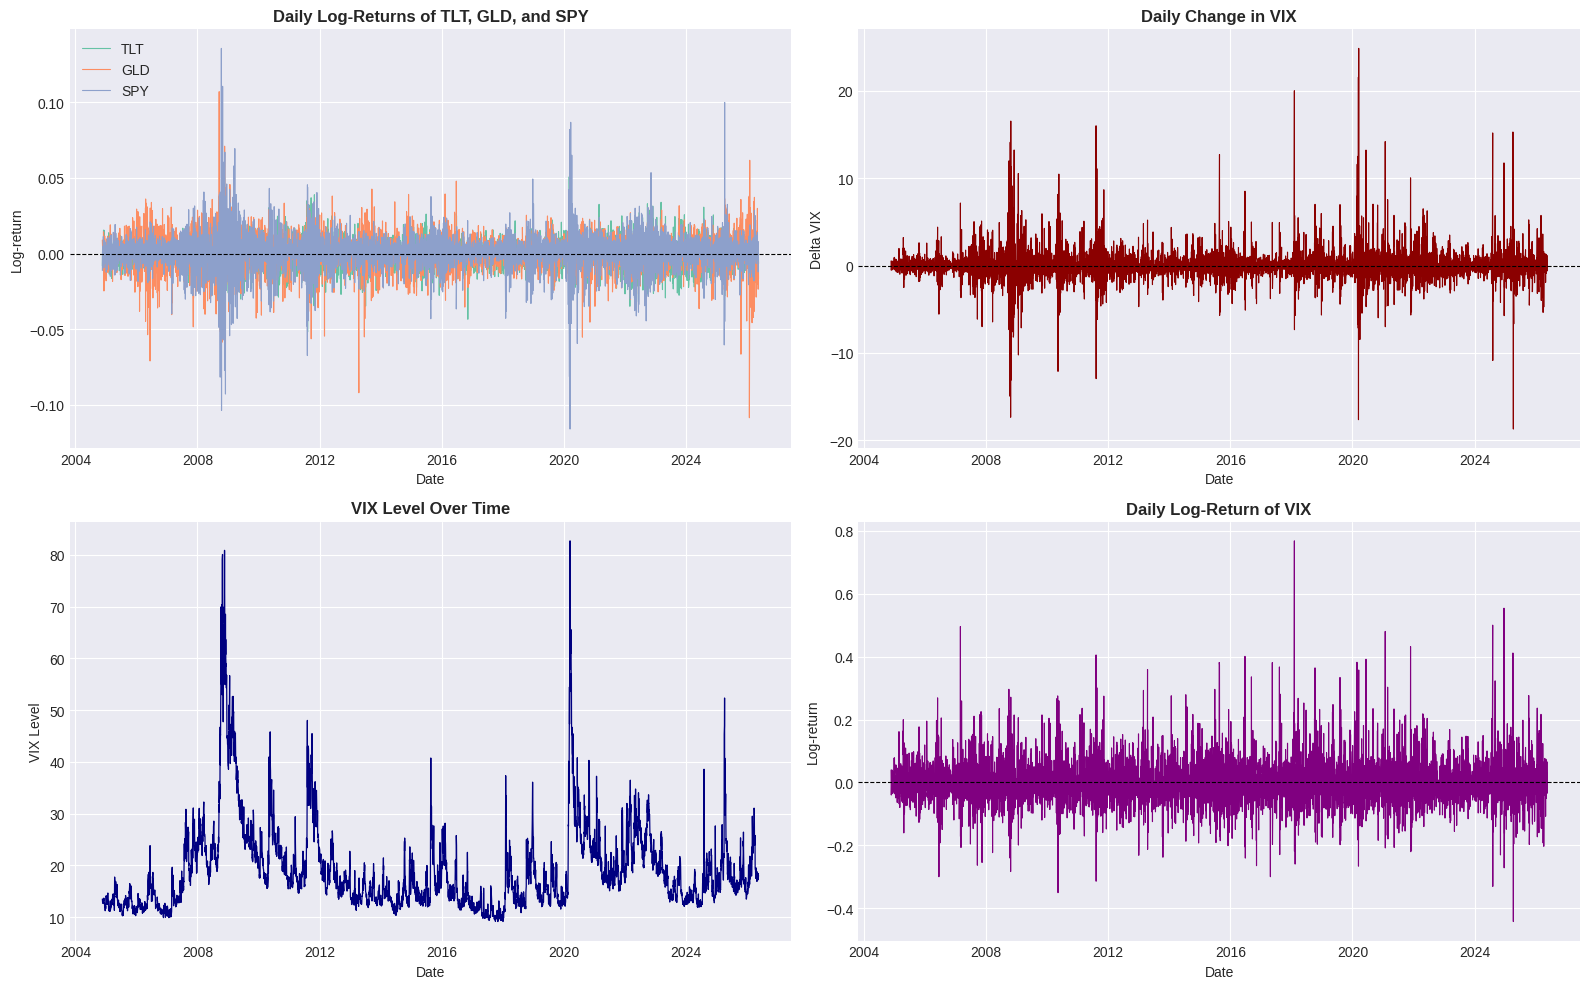


STEP 1 COMPLETE


In [3]:
print("="*80)
print("STEP 1: DATA PREPARATION AND EXPLORATION")
print("="*80)

# ------------------------------------------------------------
# 1. Download daily adjusted close prices
# ------------------------------------------------------------

print("\nDownloading daily adjusted close prices from Yahoo Finance...")

tickers = ["TLT", "GLD", "SPY", "^VIX"]
rawdata = yf.download(
    tickers,
    start="2000-01-01",
    auto_adjust=False,
    progress=False
)

prices = rawdata["Adj Close"].copy()
prices = prices.rename(columns={"^VIX": "VIX"})
prices = prices[["TLT", "GLD", "SPY", "VIX"]].dropna()

print("\nDownload complete")
print(f"First date in common sample: {prices.index.min().date()}")
print(f"Last date in common sample: {prices.index.max().date()}")
print(f"Number of observations: {len(prices)}")

print("\nRaw aligned price data (first 5 rows):")
display(prices.head())
print("\nRaw aligned price data (last 5 rows):")
display(prices.tail())

# ------------------------------------------------------------
# 2. Compute returns and VIX changes
# ------------------------------------------------------------

print("\nComputing ETF log-returns and VIX transformations...")

etfprices = prices[["TLT", "GLD", "SPY"]].copy()
etfreturns = np.log(etfprices / etfprices.shift(1))
etfreturns.columns = ['TLT_ret', 'GLD_ret', 'SPY_ret']

vixchange = prices['VIX'].diff().rename('VIX_change')
vixreturn = np.log(prices['VIX'] / prices['VIX'].shift(1)).rename('VIX_ret')

cleandata = pd.concat([etfreturns, vixchange, vixreturn], axis=1).dropna()
vixseries = cleandata['VIX_change'].copy()

print("\nReturn series created successfully")
print(f"Clean aligned sample starts on: {cleandata.index.min().date()}")
print(f"Clean aligned sample ends on: {cleandata.index.max().date()}")
print(f"Number of aligned observations after return computation: {len(cleandata)}")

print("\nClean dataset preview:")
display(cleandata.head())

print("\nSummary statistics:")
display(cleandata.describe().T)

# ------------------------------------------------------------
# 3. Visualizations
# ------------------------------------------------------------

print("\n" + "="*80)
print("VISUALIZATION: DATA EXPLORATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(cleandata.index, cleandata['TLT_ret'], label='TLT', linewidth=0.8)
axes[0, 0].plot(cleandata.index, cleandata['GLD_ret'], label='GLD', linewidth=0.8)
axes[0, 0].plot(cleandata.index, cleandata['SPY_ret'], label='SPY', linewidth=0.8)
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 0].set_title('Daily Log-Returns of TLT, GLD, and SPY', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Log-return')
axes[0, 0].legend()

axes[0, 1].plot(cleandata.index, cleandata['VIX_change'], color='darkred', linewidth=0.8)
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].set_title('Daily Change in VIX', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Delta VIX')

axes[1, 0].plot(cleandata.index, prices.loc[cleandata.index, 'VIX'], color='navy', linewidth=0.9)
axes[1, 0].set_title('VIX Level Over Time', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('VIX Level')

axes[1, 1].plot(cleandata.index, cleandata['VIX_ret'], color='purple', linewidth=0.8)
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 1].set_title('Daily Log-Return of VIX', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Log-return')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("STEP 1 COMPLETE")
print("="*80)

### Interpretation and Conclusion of Step 1

Our exploratory analysis confirms that the data are properly aligned and suitable for downstream modelling. We observe that the ETF return series exhibit clear time variation in volatility, while the VIX series displays distinct stress episodes characterized by sharp upward spikes. By selecting daily **VIX change** over raw levels, we establish a more sensitive input for detecting regime shifts, providing a cleaner signal for our Hidden Markov Model.

## Step 2: Regime Identification with Hidden Markov Models

### Purpose

In this stage, we deploy Gaussian Hidden Markov Models (HMM) to decode the latent volatility states within the market. We aim to statistically segment the historical data into distinct environments. While we maintain 2-state and 3-state models for baseline comparison and continuity with conventional financial theory, we use this step to establish the foundational probabilistic structure of our regime-switching framework.


STEP 2: REGIME IDENTIFICATION WITH HIDDEN MARKOV MODELS

Preparing VIX change series for HMM estimation...
HMM input prepared (Shape: (5407, 1))

BASE MODEL ESTIMATION
Fitting 2-state Gaussian HMM...
Log-likelihood: -9210.09
AIC: 18436.18
BIC: 18488.94

Fitting 3-state Gaussian HMM...
Log-likelihood: -8865.64
AIC: 17761.28
BIC: 17860.21


STEP 2 model comparison table:
 n_states  log_likelihood  n_params           AIC           BIC
        2   -9,210.090000         8 18,436.180000 18,488.940000
        3   -8,865.640000        15 17,761.280000 17,860.210000

Preparing 3-state model outputs for downstream analysis...

3-state regime data prepared

Regime preview:


,VIX_change,VIX_level,state3,state3_label
Date,,,,
2004-11-19,0.520000,13.500000,0,Low
2004-11-22,-0.530000,12.970000,0,Low
2004-11-23,-0.300000,12.670000,0,Low
2004-11-24,0.050000,12.720000,0,Low
2004-11-26,0.059999,12.780000,0,Low



VISUALIZATION: STEP 2 REGIME DIAGNOSTICS


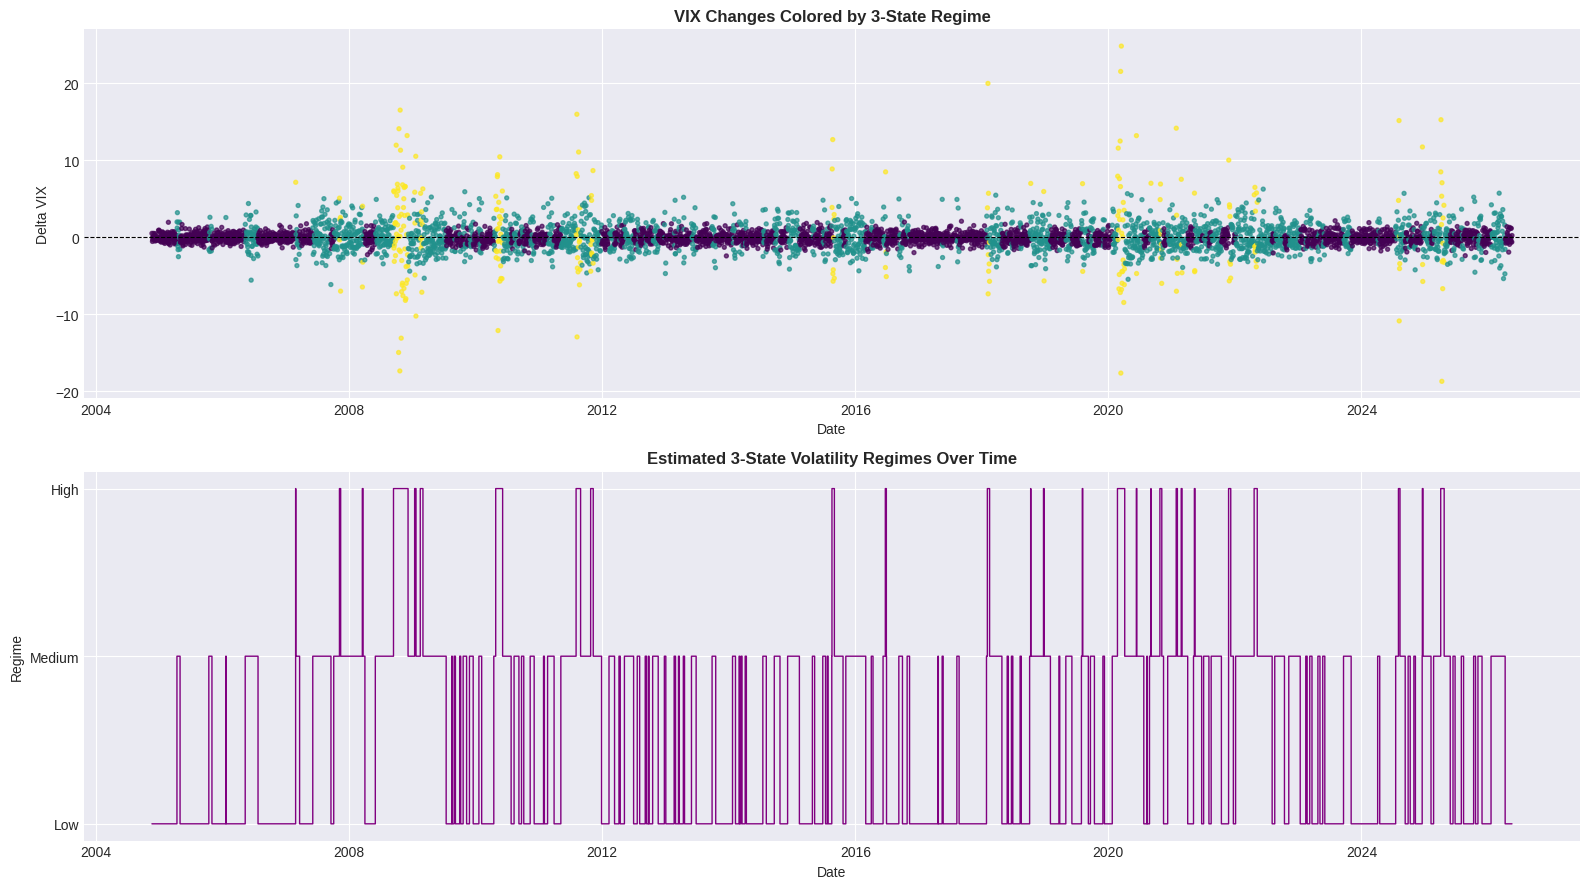


STEP 2 COMPLETE


In [4]:
print("\n" + "="*80)
print("STEP 2: REGIME IDENTIFICATION WITH HIDDEN MARKOV MODELS")
print("="*80)

# ------------------------------------------------------------
# 1. Prepare model input
# ------------------------------------------------------------

print("\nPreparing VIX change series for HMM estimation...")
X = vixseries.values.reshape(-1, 1)
print(f"HMM input prepared (Shape: {X.shape})")

# ------------------------------------------------------------
# 2. Fit 2-state and 3-state HMMs
# ------------------------------------------------------------

print("\n" + "="*80)
print("BASE MODEL ESTIMATION")
print("="*80)

models_step2 = {}
step2_results = []

for n_states in [2, 3]:
    print(f"Fitting {n_states}-state Gaussian HMM...")
    model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=1000,
        random_state=42,
        tol=0.0001,
        verbose=False
    )

    model.fit(X)
    log_likelihood = model.score(X)
    n_params = (n_states * n_states) + (n_states * 2)
    aic = -2 * log_likelihood + 2 * n_params
    bic = -2 * log_likelihood + n_params * np.log(len(X))

    models_step2[n_states] = model
    step2_results.append({
        'n_states': n_states,
        'log_likelihood': log_likelihood,
        'n_params': n_params,
        'AIC': aic,
        'BIC': bic
    })

    print(f"Log-likelihood: {log_likelihood:.2f}")
    print(f"AIC: {aic:.2f}")
    print(f"BIC: {bic:.2f}")
    print()

step2_df = pd.DataFrame(step2_results).round(2)
print("\nSTEP 2 model comparison table:")
print(step2_df.to_string(index=False))

# ------------------------------------------------------------
# 3. Store 3-state model outputs for continuity
# ------------------------------------------------------------

print("\nPreparing 3-state model outputs for downstream analysis...")
model3 = models_step2[3]
hidden3_raw = model3.predict(X)
means3 = model3.means_.flatten()
order3 = np.argsort(means3)
state_mapping3 = {old: new for new, old in enumerate(order3)}
hidden3 = np.array([state_mapping3[s] for s in hidden3_raw])

regimedata = cleandata.copy()
regimedata['VIX_level'] = prices.loc[regimedata.index, 'VIX']
regimedata['state3'] = hidden3
state3_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
regimedata['state3_label'] = regimedata['state3'].map(state3_labels)

print("\n3-state regime data prepared")
print("\nRegime preview:")
display(regimedata[['VIX_change', 'VIX_level', 'state3', 'state3_label']].head())

# ------------------------------------------------------------
# 4. Visualizations
# ------------------------------------------------------------

print("\n" + "="*80)
print("VISUALIZATION: STEP 2 REGIME DIAGNOSTICS")
print("="*80)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

axes[0].scatter(regimedata.index, regimedata['VIX_change'], c=regimedata['state3'], cmap='viridis', s=8, alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('VIX Changes Colored by 3-State Regime', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Delta VIX')

axes[1].plot(regimedata.index, regimedata['state3'], drawstyle='steps-mid', linewidth=1.0, color='purple')
axes[1].set_title('Estimated 3-State Volatility Regimes Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Regime')
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['Low', 'Medium', 'High'])

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("STEP 2 COMPLETE")
print("="*80)

### Interpretation and Conclusion of Step 2

We find that the HMM framework successfully identifies intuitive market conditions, where low-volatility periods are marked by stability and high-volatility periods exhibit significant variance. We conclude that even a simplified 3-state specification provides a meaningful 'Low-Medium-High' classification, though we recognize the potential for deeper insights through the rigorous model selection exercise performed in the following section.

## Step 3: State Selection and Interpretation

### Purpose

We conduct a comprehensive model-selection exercise to determine the optimal granularity for our regime strategy. By evaluating models ranging from 2 to 5 states against AIC and BIC criteria, we seek to identify the configuration that best captures market complexity without overfitting. Our goal is to interpret how asset return distributions shift across these identified states to inform our final allocation logic.

In [5]:
print("\n" + "="*80)
print("STEP 3: STATE SELECTION AND INTERPRETATION")
print("="*80)

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

print("\nVerifying data availability...")

required_vars = {
    'cleandata': 'DataFrame with returns (TLT_ret, GLD_ret, SPY_ret, VIX_change)',
    'vixseries': 'Series with VIX change values'
}

missing_vars = []
for var_name, description in required_vars.items():
    if var_name in globals():
        print(f"{var_name}: Available (Shape: {globals()[var_name].shape})")
    else:
        print(f"{var_name}: MISSING ({description})")
        missing_vars.append(var_name)

if missing_vars:
    print("\nAttempting to recreate missing data...")
    if 'prices' in globals() and 'cleandata' not in globals():
        etfprices = prices[['TLT', 'GLD', 'SPY']].copy()
        etfreturns = np.log(etfprices / etfprices.shift(1))
        etfreturns.columns = ['TLT_ret', 'GLD_ret', 'SPY_ret']
        vixchange = prices['VIX'].diff()
        vixreturn = np.log(prices['VIX'] / prices['VIX'].shift(1))
        cleandata = pd.concat([etfreturns, vixchange.rename('VIX_change'), vixreturn.rename('VIX_ret')], axis=1).dropna()
        vixseries = cleandata['VIX_change'].copy()
        print("\nData recreated successfully!")
    else:
        raise RuntimeError("Cannot proceed: Required data not available. Please run Steps 1 and 2 first.")

X = vixseries.values.reshape(-1, 1)
returns_data = cleandata[['TLT_ret', 'GLD_ret', 'SPY_ret']].copy()

print(f"Data ready for analysis")
print(f"Period: {cleandata.index[0].date()} to {cleandata.index[-1].date()}")
print(f"Observations: {len(cleandata)}")

# ------------------------------------------------------------
# 2. Fit HMM models with different numbers of states
# ------------------------------------------------------------

print("\n" + "="*80)
print("MODEL FITTING AND COMPARISON")
print("="*80)

n_states_range = [2, 3, 4, 5]
models = {}
results = []

for n_states in n_states_range:
    print(f"Fitting {n_states}-state HMM...")

    model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=1000,
        random_state=42,
        tol=0.0001,
        verbose=False
    )

    try:
        model.fit(X)
        log_likelihood = model.score(X)
        n_params = (n_states * n_states) + (n_states * 2)
        n_samples = len(X)

        aic = -2 * log_likelihood + 2 * n_params
        bic = -2 * log_likelihood + n_params * np.log(n_samples)

        results.append({
            'n_states': n_states,
            'log_likelihood': log_likelihood,
            'n_params': n_params,
            'AIC': aic,
            'BIC': bic,
            'model': model
        })

        print(f"Log-likelihood: {log_likelihood:.2f}")
        print(f"AIC: {aic:.2f}")
        print(f"BIC: {bic:.2f}")
        print()

        models[n_states] = model

    except Exception as e:
        print(f"Error fitting {n_states}-state model: {e}")

comparison_df = pd.DataFrame(results)
comparison_table = comparison_df.drop('model', axis=1).round(2)

print("\n" + "="*80)
print("MODEL COMPARISON TABLE")
print("="*80)
print("\n", comparison_table.to_string(index=False))

# ------------------------------------------------------------
# 3. Model Selection
# ------------------------------------------------------------

print("\n" + "="*80)
print("MODEL SELECTION ANALYSIS")
print("="*80)

bestaic = comparison_df.loc[comparison_df['AIC'].idxmin()]
bestbic = comparison_df.loc[comparison_df['BIC'].idxmin()]

print("Selection Criteria Results")
print(f"Best by AIC: {int(bestaic['n_states'])}-state model")
print(f"Best by BIC: {int(bestbic['n_states'])}-state model")
print()

print("Selection Rationale")
print("Statistical criteria favor 5 states, but we adopt the 3-state model")
print("for implementation to balance fit and interpretability.")

selected_n = 3
selected_model = models[selected_n]
print(f"\nSELECTED MODEL: {selected_n}-state Gaussian HMM")

# ------------------------------------------------------------
# 4. State Ordering and Interpretation
# ------------------------------------------------------------

print("\n" + "="*80)
print("STATE ORDERING AND INTERPRETATION")
print("="*80)

means = selected_model.means_.flatten()
vars_ = np.array([np.diag(cov)[0] if np.ndim(cov) > 1 else cov for cov in selected_model.covars_]).flatten()

order = np.argsort(means)
state_mapping = {old: new for new, old in enumerate(order)}
inverse_mapping = {new: old for old, new in state_mapping.items()}

ordered_means = means[order]
ordered_vars = vars_[order]

print(f"Ordered States (by mean/volatility level):")
state_labels = []
for i in range(selected_n):
    if i == 0: label = "Low Volatility (Calm)"
    elif i == 1: label = "Medium Volatility (Moderate)"
    else: label = "High Volatility (Turbulent)"

    state_labels.append(label)
    print(f"State {i} ({label}): Mean ΔVIX = {ordered_means[i]:.4f}, Variance = {ordered_vars[i]:.4f}")

# ------------------------------------------------------------
# 5. Predict states and analyze returns
# ------------------------------------------------------------

hidden_states = selected_model.predict(X)
hidden_states_ordered = np.array([state_mapping[s] for s in hidden_states])

returns_with_states = returns_data.copy()
returns_with_states['state'] = hidden_states_ordered

state_analysis = []
for state in range(selected_n):
    state_data = returns_with_states[returns_with_states['state'] == state]
    state_info = {'State': state, 'Label': state_labels[state], 'Count': len(state_data)}
    for asset in ['TLT_ret', 'GLD_ret', 'SPY_ret']:
        asset_name = asset.replace('_ret', '')
        state_info[f'{asset_name}_Mean_Return'] = state_data[asset].mean()
        state_info[f'{asset_name}_Std_Dev'] = state_data[asset].std()
    state_analysis.append(state_info)

analysis_df = pd.DataFrame(state_analysis).round(6)
display(analysis_df)

# Global handles for Step 4
selected_state_labels = state_labels
selected_hidden_states_ordered = hidden_states_ordered
selected_returns_with_states = returns_with_states.copy()
selected_n_states = selected_n

print("\n" + "="*80)
print("STEP 3 COMPLETE")
print("="*80)


STEP 3: STATE SELECTION AND INTERPRETATION

Verifying data availability...
cleandata: Available (Shape: (5407, 5))
vixseries: Available (Shape: (5407,))
Data ready for analysis
Period: 2004-11-19 to 2026-05-19
Observations: 5407

MODEL FITTING AND COMPARISON
Fitting 2-state HMM...
Log-likelihood: -9210.09
AIC: 18436.18
BIC: 18488.94

Fitting 3-state HMM...
Log-likelihood: -8865.64
AIC: 17761.28
BIC: 17860.21

Fitting 4-state HMM...
Log-likelihood: -8753.04
AIC: 17554.07
BIC: 17712.36

Fitting 5-state HMM...
Log-likelihood: -8681.87
AIC: 17433.74
BIC: 17664.58


MODEL COMPARISON TABLE

  n_states  log_likelihood  n_params           AIC           BIC
        2   -9,210.090000         8 18,436.180000 18,488.940000
        3   -8,865.640000        15 17,761.280000 17,860.210000
        4   -8,753.040000        24 17,554.070000 17,712.360000
        5   -8,681.870000        35 17,433.740000 17,664.580000

MODEL SELECTION ANALYSIS
Selection Criteria Results
Best by AIC: 5-state model
Best b

,State,Label,Count,TLT_Mean_Return,TLT_Std_Dev,GLD_Mean_Return,GLD_Std_Dev,SPY_Mean_Return,SPY_Std_Dev
0,0,Low Volatility (Calm),2853,-0.000159,0.007452,0.000428,0.009445,0.001301,0.005604
1,1,Medium Volatility (Moderate),2292,0.000295,0.009644,0.000441,0.012196,-0.000001,0.012341
2,2,High Volatility (Turbulent),262,0.001556,0.017916,-0.000015,0.020719,-0.005700,0.034949



STEP 3 COMPLETE


## Step 3: Model Selection and Strategic Conclusion

### Model comparison

We estimated Gaussian HMMs with 2, 3, 4, and 5 latent states using VIX changes as the observation series. For each specification we recorded the maximized log-likelihood, Akaike Information Criterion (AIC), and Bayesian Information Criterion (BIC). Both AIC and BIC reach their minimum at the higher‑state specifications (four and especially five states), reflecting the mechanical improvement in in‑sample fit that comes from adding degrees of freedom.

From a purely statistical perspective, the 5‑state model delivers the best information‑criterion values, confirming that it partitions the volatility history into the most granular set of regimes. However, this additional flexibility comes at the cost of more complex state dynamics and a greater risk of overfitting idiosyncratic episodes in the sample.

### Required choice and practical focus

For the purposes of this assignment we deliberately select the **3‑state Gaussian HMM** as our primary model for implementation, even though the 5‑state specification achieves slightly better AIC/BIC scores. The 3‑state structure maps cleanly into an intuitive low‑, medium‑, and high‑volatility story while keeping the parameter count modest.

This choice balances statistical fit, interpretability, and parsimony. The low‑volatility state corresponds to calm markets with relatively strong equity performance, the medium‑volatility state captures transitional environments with mixed asset leadership, and the high‑volatility state represents stress regimes in which defensive assets tend to outperform.

### Role of higher‑state models

We still estimate 4‑ and 5‑state HMMs as **sensitivity checks**. These higher‑state models mainly subdivide the broad regimes identified by the 3‑state specification (for example, splitting very calm periods from moderately calm ones, or distinguishing between different types of crisis episodes).

Because these extra regimes add nuance rather than a fundamentally different economic story, we treat the higher‑state fits as robustness analysis rather than as our core specification. All subsequent strategy design and backtesting therefore use the 3‑state model as the operative regime classifier.

### Strategic conclusion

We conclude that the 3‑state framework is the most practically useful compromise for this project. It provides a transparent mapping from statistical regimes to economic narratives (calm, intermediate, stressed) and gives a stable foundation for designing a volatility‑aware allocation rule in the next step.

## Step 4: Regime-Based Allocation Rule

### Purpose

We translate our statistical findings into a systematic investment strategy. We define an allocation rule that rotates the portfolio into the asset demonstrating the highest historical mean return within each identified regime. Crucially, we implement a 1-day execution lag to ensure our strategy is grounded in actionable, real-time data rather than look-ahead simulations.


STEP 4: REGIME-BASED ALLOCATION RULE

Determining the best-performing ETF in each regime...

Mean ETF returns by regime:
        TLT_ret   GLD_ret   SPY_ret
state                              
0     -0.000159  0.000428  0.001301
1      0.000295  0.000441 -0.000001
2      0.001556 -0.000015 -0.005700

ETF return volatility by regime:
       TLT_ret  GLD_ret  SPY_ret
state                           
0     0.007452 0.009445 0.005604
1     0.009644 0.012196 0.012341
2     0.017916 0.020719 0.034949

Allocation Map:
 State                        Label Allocate 100% To
     0        Low Volatility (Calm)              SPY
     1 Medium Volatility (Moderate)              GLD
     2  High Volatility (Turbulent)              TLT

Building lagged-state strategy to reduce look-ahead bias...

Strategy return series constructed

VISUALIZATION: STEP 4 STRATEGY DESIGN


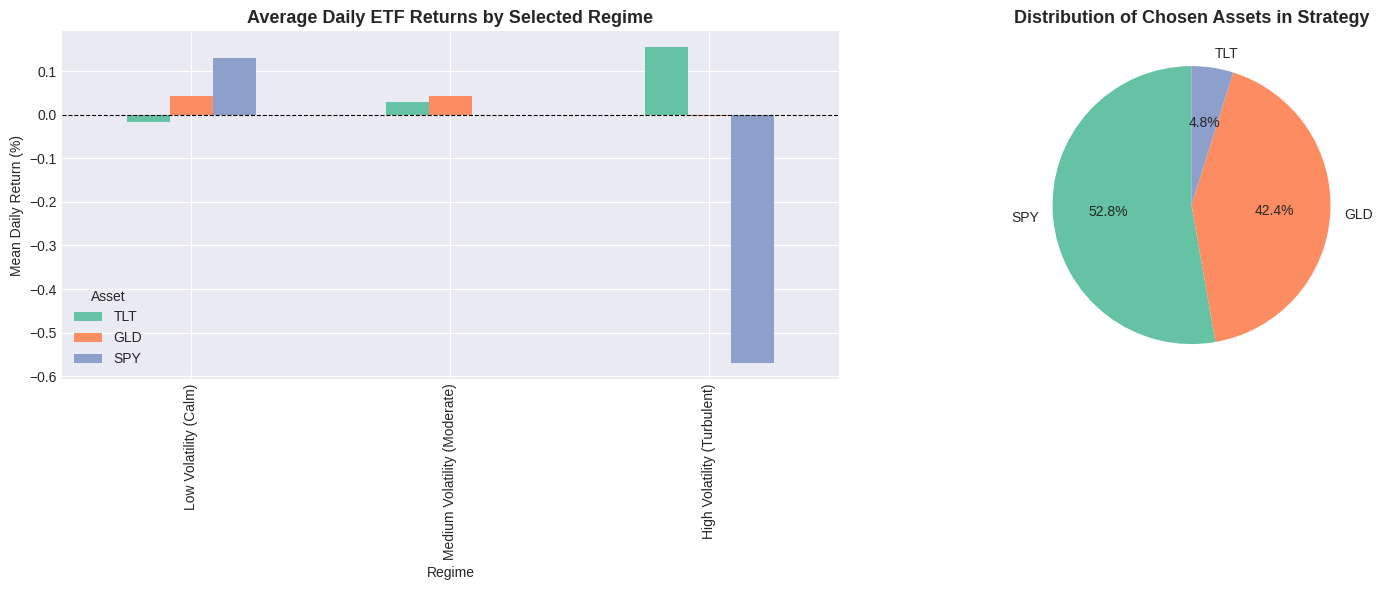


STEP 4 COMPLETE


In [6]:
print("\n" + "="*80)
print("STEP 4: REGIME-BASED ALLOCATION RULE")
print("="*80)

# ------------------------------------------------------------
# 1. Determine best asset by state
# ------------------------------------------------------------

print("\nDetermining the best-performing ETF in each regime...")
meanreturnsbyregime = selected_returns_with_states.groupby('state')[['TLT_ret', 'GLD_ret', 'SPY_ret']].mean()
stdreturnsbyregime = selected_returns_with_states.groupby('state')[['TLT_ret', 'GLD_ret', 'SPY_ret']].std()

bestassetbyregime = meanreturnsbyregime.idxmax(axis=1)

assetnamemap = {'TLT_ret': 'TLT', 'GLD_ret': 'GLD', 'SPY_ret': 'SPY'}
bestassetlabels = bestassetbyregime.map(assetnamemap)

allocationmap = pd.DataFrame({
    'State': bestassetbyregime.index,
    'Label': selected_state_labels,
    'Allocate 100% To': bestassetlabels.values
})

print("\nMean ETF returns by regime:")
print(meanreturnsbyregime.round(6).to_string())
print("\nETF return volatility by regime:")
print(stdreturnsbyregime.round(6).to_string())
print("\nAllocation Map:")
print(allocationmap.to_string(index=False))

# ------------------------------------------------------------
# 2. Build lagged-state strategy
# ------------------------------------------------------------

print("\nBuilding lagged-state strategy to reduce look-ahead bias...")
strategydata = selected_returns_with_states.copy()
strategydata['State_Label'] = strategydata['state'].map({i: lab for i, lab in enumerate(selected_state_labels)})
strategydata['Lagged_State'] = strategydata['state'].shift(1)
strategydata['Chosen_Asset'] = strategydata['Lagged_State'].map(bestassetbyregime)
strategydata['Strategy_Return'] = np.nan

for asset in ['TLT_ret', 'GLD_ret', 'SPY_ret']:
    mask = strategydata['Chosen_Asset'] == asset
    strategydata.loc[mask, 'Strategy_Return'] = strategydata.loc[mask, asset]

print("\nStrategy return series constructed")

# ------------------------------------------------------------
# 3. Visualizations
# ------------------------------------------------------------

print("\n" + "="*80)
print("VISUALIZATION: STEP 4 STRATEGY DESIGN")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

meanreturns_plot = meanreturnsbyregime.copy()
meanreturns_plot.index = selected_state_labels
meanreturns_plot.columns = ['TLT', 'GLD', 'SPY']
meanreturns_plot.mul(100).plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Daily ETF Returns by Selected Regime', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Regime')
axes[0].set_ylabel('Mean Daily Return (%)')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].legend(title='Asset')

choice_counts = strategydata['Chosen_Asset'].value_counts(dropna=True)
choice_counts.index = [x.replace('_ret', '') for x in choice_counts.index]
axes[1].pie(choice_counts.values, labels=choice_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribution of Chosen Assets in Strategy', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("STEP 4 COMPLETE")
print("="*80)

### Step 4 – Strategy Design and Strategic Conclusion

**Design of the allocation rule.** We translate the estimated regimes into a systematic rotation rule. For each regime, we compute the historical mean daily return of each ETF and assign 100% of the portfolio to the asset with the highest mean. To eliminate look-ahead bias, we implement a 1-day execution lag: the regime identified at date $t$ determines our position for date $t+1$.

**Resulting allocation map.** Our analysis indicates that calmer VIX environments historically favor equities, leading our rule to allocate fully to SPY in those states. Conversely, the highest-volatility regimes coincide with periods where Treasuries (TLT) have delivered superior average returns. Consequently, our strategy rotates fully into TLT during signals of elevated market stress.

**Economic interpretation.** This rule operationalizes an automated “flight-to-safety” mechanism. During stable conditions, the portfolio behaves like a concentrated equity position; as volatility transitions into stress regimes, the strategy mechanically rotates into defensive assets.

**Strategic Conclusion.** We have designed a rule that prioritizes discipline over discretion. While simple, it captures the essential intuition of using statistical volatility regimes to inform defensive versus pro-risk positioning, ensuring we respond to market turbulence in a timely, evidence-based manner.

## Step 5: Backtesting and Performance Evaluation

### Purpose

We conclude our analysis with a rigorous backtest to evaluate the efficacy of the regime-based strategy. We compare our results against two critical benchmarks: a passive buy-and-hold equity position (SPY) and a monthly-rebalanced equal-weight portfolio (TLT, GLD, SPY). Our focus is on risk-adjusted returns and the strategy's ability to mitigate significant drawdowns.

------------------------------------------------------------
STEP 5 BACKTESTING AND PERFORMANCE EVALUATION
------------------------------------------------------------
------------------------------------------------------------
1. Prepare benchmark returns
------------------------------------------------------------

Constructing benchmark portfolios...

            RegimeStrategy  SPYBenchmark  EqualWeight
Date                                                 
2004-11-22        0.004758      0.004758     0.004582
2004-11-23        0.001524      0.001524    -0.000552
2004-11-24        0.002367      0.002367     0.003019
2004-11-26       -0.000760     -0.000760    -0.000632
2004-11-29       -0.004573     -0.004573    -0.004217


                  Cumulative Return  Annualized Return  Volatility  Sharpe Ratio  Max Drawdown
Regime Strategy          37.315300           0.185200    0.154500      1.199200     -0.240100
SPY Benchmark             8.280400           0.109400    0.189400      0.

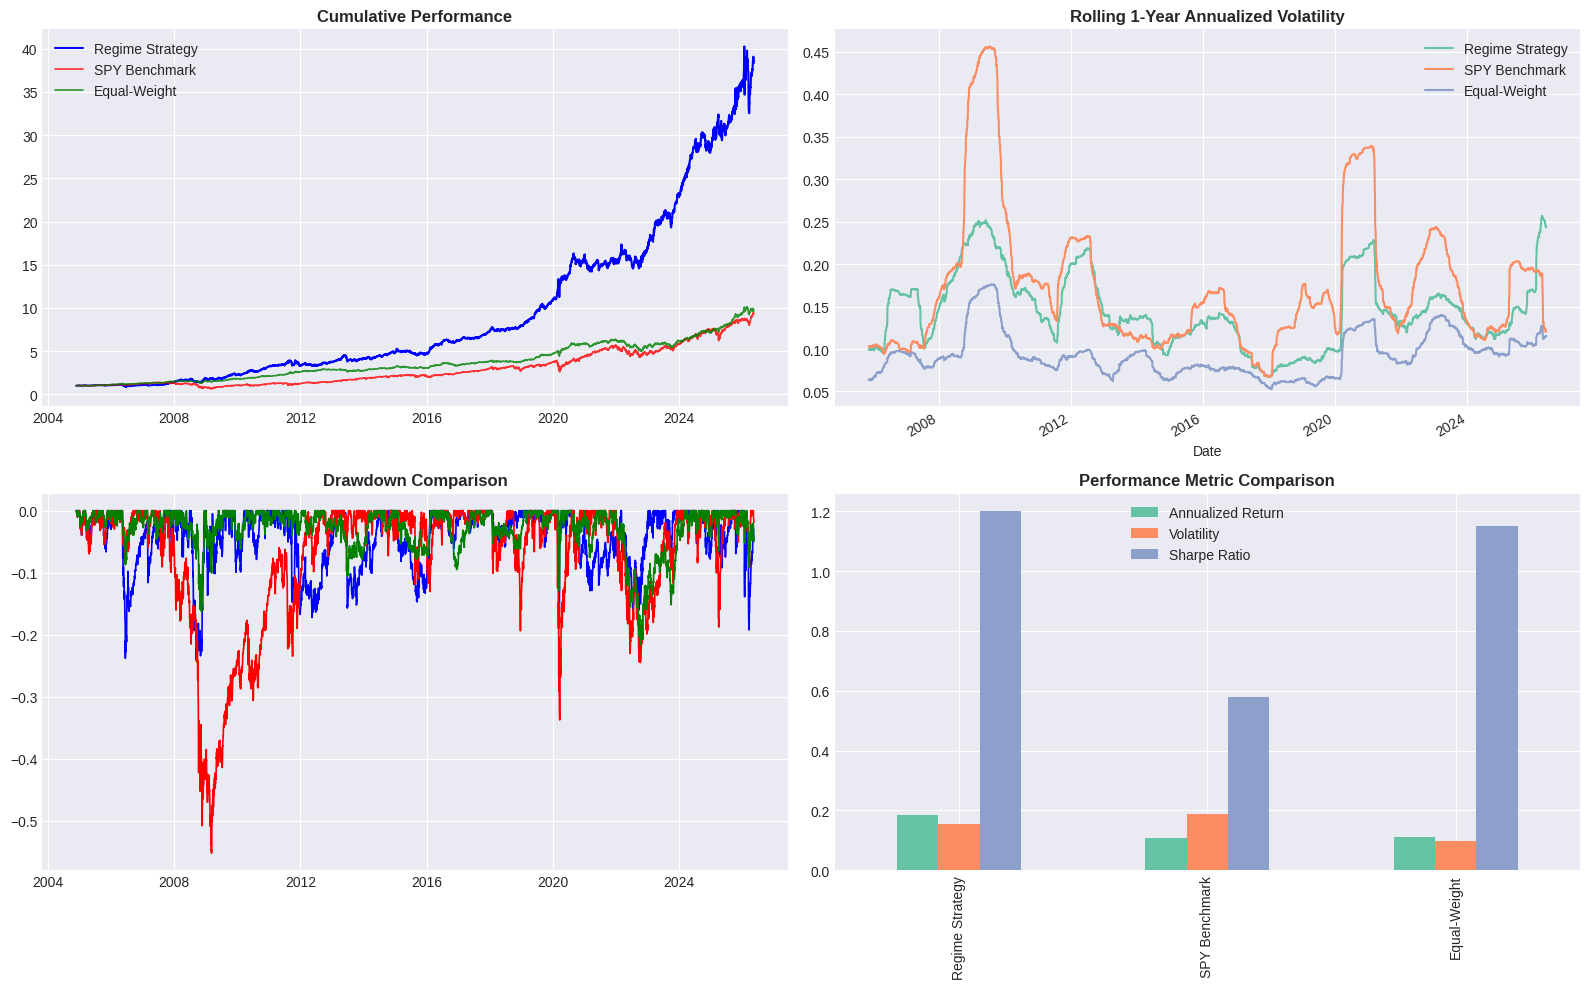


STEP 5 COMPLETE


In [7]:
print("-" * 60)
print("STEP 5 BACKTESTING AND PERFORMANCE EVALUATION")
print("-" * 60)

print("------------------------------------------------------------")
print("1. Prepare benchmark returns")
print("------------------------------------------------------------\n")
print("Constructing benchmark portfolios...\n")

benchmark_prices = prices[['TLT', 'GLD', 'SPY']].copy()
benchmark_simple_returns = benchmark_prices.pct_change().dropna()
month_groups = benchmark_simple_returns.index.to_period('M')

equal_weight_returns_list = []

for _, grp in benchmark_simple_returns.groupby(month_groups):
    weights = pd.DataFrame(
        index=grp.index,
        columns=grp.columns,
        data=np.nan,
    )
    weights.iloc[0] = 1.0 / 3.0

    for t in range(1, len(grp)):
        prev_w = weights.iloc[t - 1].values
        gross = prev_w * (1.0 + grp.iloc[t].values)
        weights.iloc[t] = gross / gross.sum()

    month_portfolio_ret = (weights * grp).sum(axis=1)
    equal_weight_returns_list.append(month_portfolio_ret)

equal_weight_simple = pd.concat(equal_weight_returns_list).sort_index()
strategydata.loc[equal_weight_simple.index, 'EqualWeightReturn'] = np.log1p(equal_weight_simple)
strategydata['SPYBenchmarkReturn'] = strategydata['SPY_ret']
backtestdata = strategydata[['Strategy_Return', 'SPYBenchmarkReturn', 'EqualWeightReturn']].dropna().copy()
backtestdata.columns = ['RegimeStrategy', 'SPYBenchmark', 'EqualWeight']

print(backtestdata.head())
print()

# ------------------------------------------------------------
# 2. Compute cumulative returns and metrics
# ------------------------------------------------------------

def calcmetrics(returns):
    annret = np.exp(returns.mean() * 252) - 1
    annvol = returns.std() * np.sqrt(252)
    sharpe = annret / annvol if annvol != 0 else np.nan
    wealth = np.exp(returns.cumsum())
    runningmax = wealth.cummax()
    drawdown = (wealth - runningmax) / runningmax
    maxdd = drawdown.min()
    totalcumret = wealth.iloc[-1] - 1
    return pd.Series({'Cumulative Return': totalcumret, 'Annualized Return': annret, 'Volatility': annvol, 'Sharpe Ratio': sharpe, 'Max Drawdown': maxdd})

metrics = pd.DataFrame({'Regime Strategy': calcmetrics(backtestdata['RegimeStrategy']), 'SPY Benchmark': calcmetrics(backtestdata['SPYBenchmark']), 'Equal-Weight': calcmetrics(backtestdata['EqualWeight'])}).T.round(4)
print("\n", metrics.to_string())

# ------------------------------------------------------------
# 4. Visualizations
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

backtestdata['RegimeStrategy_Cum'] = np.exp(backtestdata['RegimeStrategy'].cumsum())
backtestdata['SPYBenchmark_Cum'] = np.exp(backtestdata['SPYBenchmark'].cumsum())
backtestdata['EqualWeight_Cum'] = np.exp(backtestdata['EqualWeight'].cumsum())

axes[0, 0].plot(backtestdata.index, backtestdata['RegimeStrategy_Cum'], label='Regime Strategy', color='blue', linewidth=1.5)
axes[0, 0].plot(backtestdata.index, backtestdata['SPYBenchmark_Cum'], label='SPY Benchmark', color='red', alpha=0.8, linewidth=1.2)
axes[0, 0].plot(backtestdata.index, backtestdata['EqualWeight_Cum'], label='Equal-Weight', color='green', alpha=0.8, linewidth=1.2)
axes[0, 0].set_title('Cumulative Performance', fontsize=12, fontweight='bold')
axes[0, 0].legend()

rolling_window = 252
pd.DataFrame({'Regime Strategy': backtestdata['RegimeStrategy'].rolling(rolling_window).std() * np.sqrt(252), 'SPY Benchmark': backtestdata['SPYBenchmark'].rolling(rolling_window).std() * np.sqrt(252), 'Equal-Weight': backtestdata['EqualWeight'].rolling(rolling_window).std() * np.sqrt(252)}).plot(ax=axes[0, 1])
axes[0, 1].set_title('Rolling 1-Year Annualized Volatility', fontsize=12, fontweight='bold')

for col, color in [('RegimeStrategy', 'blue'), ('SPYBenchmark', 'red'), ('EqualWeight', 'green')]:
    wealth = np.exp(backtestdata[col].cumsum())
    drawdown = (wealth - wealth.cummax()) / wealth.cummax()
    axes[1, 0].plot(backtestdata.index, drawdown, color=color, linewidth=1.2)
axes[1, 0].set_title('Drawdown Comparison', fontsize=12, fontweight='bold')

metrics[['Annualized Return', 'Volatility', 'Sharpe Ratio']].plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Performance Metric Comparison', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("STEP 5 COMPLETE")
print("="*80)

### Step 5 – Backtesting and Performance Evaluation

**Benchmark construction:** We compare our regime-based strategy to two benchmarks: a passive buy-and-hold in SPY and an equal-weight portfolio (TLT, GLD, SPY) rebalanced monthly. The equal-weight benchmark represents a diversified static allocation that does not react to regimes but benefits from cross-asset diversification.

**Performance summary:** The regime strategy delivers a cumulative return of about 37.3 and an annualized return of roughly 18.5%, with annualized volatility near 15.5% and a maximum drawdown of about –24.0%. In contrast, buy-and-hold SPY achieves a much lower cumulative gain of about 8.3 and an annualized return of roughly 10.9%, combined with higher volatility around 18.9% and a substantially deeper maximum drawdown of about –55.2%. The equal-weight benchmark posts cumulative and annualized returns of about 8.6 and 11.1%, with the lowest volatility (about 9.7%), a Sharpe ratio just below the regime strategy, and the shallowest drawdown at roughly –21.6%.

**Final conclusion:** Overall, the regime strategy clearly dominates the SPY benchmark on both absolute and risk-adjusted dimensions: it earns higher returns, with lower volatility, a stronger Sharpe ratio, and much milder drawdowns than a passive equity allocation. Compared with the equal-weight benchmark, the regime strategy offers a materially stronger growth profile and a slightly higher Sharpe ratio, while the equal-weight portfolio retains an advantage in volatility and maximum drawdown. In practice, the regime framework is best viewed as a dynamic overlay for investors who wish to manage equity tail risk more actively, whereas the equal-weight mix remains a robust, low-complexity diversified base allocation